<a href="https://colab.research.google.com/github/dohaalnabahin/Data_science_and_machine_learning_Journey/blob/main/MA_RA_ARMA_Models_(Practice).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.tsa.api as tsa
from pmdarima.arima.utils import ndiffs

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/example_time_series.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")
df = df.sort_index()

df.index.freq = "W"

df.head()

,ts_1,ts_2,ts_3,ts_4,ts_5,ts_6
Date,,,,,,
2020-01-05,0.422207,-0.334830,-0.194485,0.304119,0.335330,0.628650
2020-01-12,-0.455290,-0.343508,-0.649775,0.385431,0.253175,-0.062857
2020-01-19,0.914767,-0.080714,0.264993,0.987436,0.202251,0.474599
2020-01-26,0.562761,0.010582,0.827754,0.830760,0.137298,-0.591919
2020-02-02,-0.649239,-0.088101,0.178515,-0.827785,0.305798,-0.372528


In [5]:
ts_1 = df["ts_1"]
ts_2 = df["ts_2"]
ts_3 = df["ts_3"]
ts_4 = df["ts_4"]
ts_5 = df["ts_5"]
ts_6 = df["ts_6"]

series_list = {
    "ts_1": ts_1,
    "ts_2": ts_2,
    "ts_3": ts_3,
    "ts_4": ts_4,
    "ts_5": ts_5,
    "ts_6": ts_6
}

In [6]:
def analyze_time_series(ts, name, nlags=30):
    print("="*60)
    print(f"Analysis for {name}")
    print("="*60)

    # 1. Plot original series
    ts.plot(figsize=(10,3), title=f"{name} - Original Time Series")
    plt.show()

    # 2. ADF test
    adf_result = tsa.adfuller(ts.dropna())
    p_value = adf_result[1]

    print(f"ADF p-value: {p_value:.5f}")

    if p_value < 0.05:
        print("Stationary: Yes")
    else:
        print("Stationary: No")

    # 3. ndiffs
    d = ndiffs(ts.dropna())
    print(f"Suggested d from ndiffs: {d}")

    # 4. Difference if needed
    if d > 0:
        ts_stationary = ts.diff(d).dropna()
        print(f"Using differenced data with d = {d}")
    else:
        ts_stationary = ts.dropna()
        print("Using original data because d = 0")

    # 5. Plot stationary version
    ts_stationary.plot(figsize=(10,3), title=f"{name} - Stationary Version")
    plt.show()

    # 6. ACF / PACF
    fig, axes = plt.subplots(2, 1, figsize=(10,6))

    tsa.graphics.plot_acf(ts_stationary, lags=nlags, ax=axes[0])
    axes[0].set_title(f"{name} - ACF")

    tsa.graphics.plot_pacf(ts_stationary, lags=nlags, ax=axes[1])
    axes[1].set_title(f"{name} - PACF")

    plt.tight_layout()
    plt.show()

    print("Interpretation guide:")
    print("PACF cutoff → choose p")
    print("ACF cutoff  → choose q")
    print(f"Final model form: ARIMA(p, {d}, q)")

Analysis for ts_1


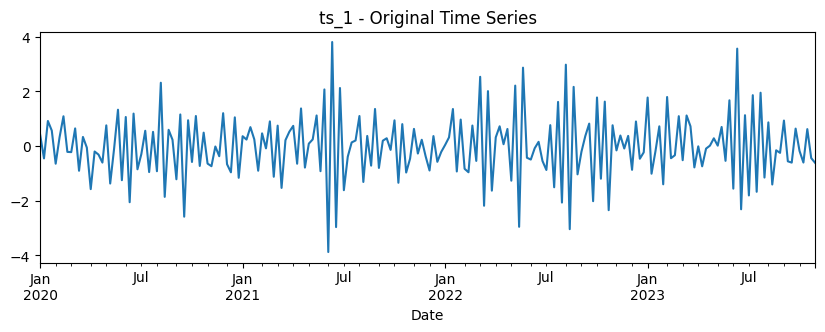

ADF p-value: 0.00000
Stationary: Yes
Suggested d from ndiffs: 0
Using original data because d = 0


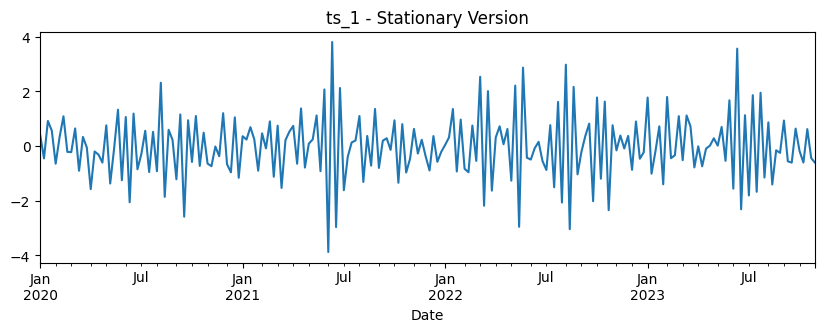

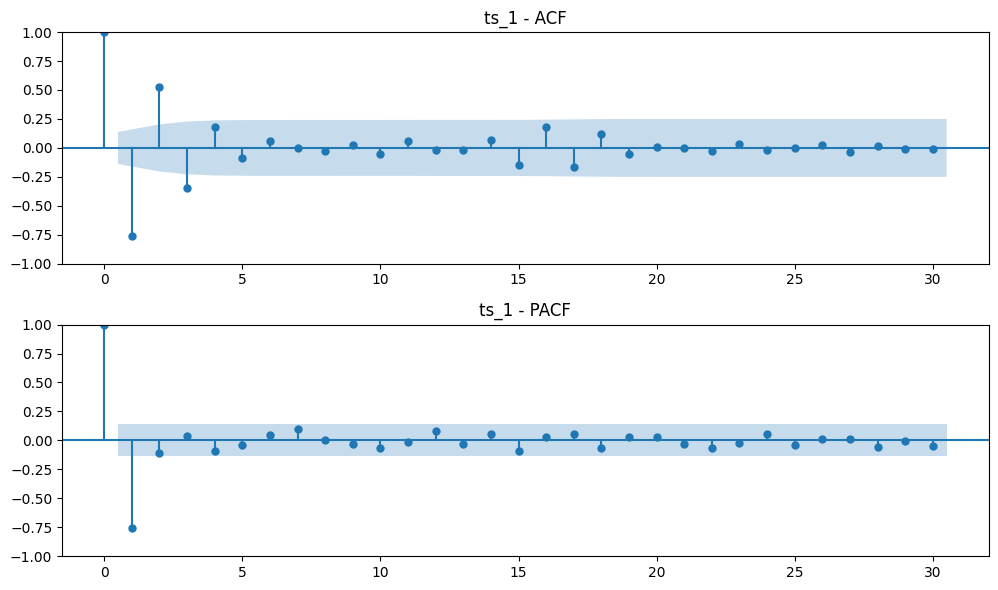

Interpretation guide:
PACF cutoff → choose p
ACF cutoff  → choose q
Final model form: ARIMA(p, 0, q)
Analysis for ts_2


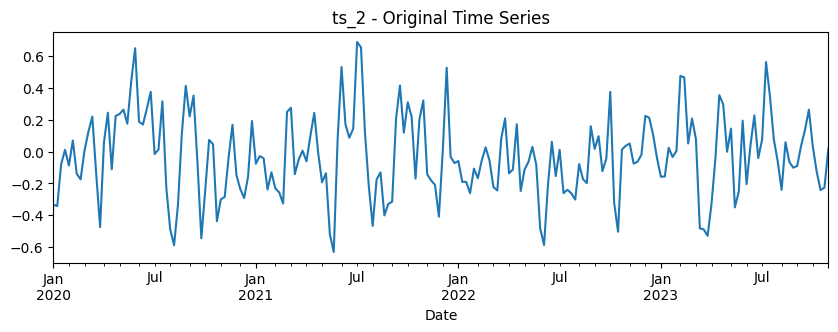

ADF p-value: 0.00000
Stationary: Yes
Suggested d from ndiffs: 0
Using original data because d = 0


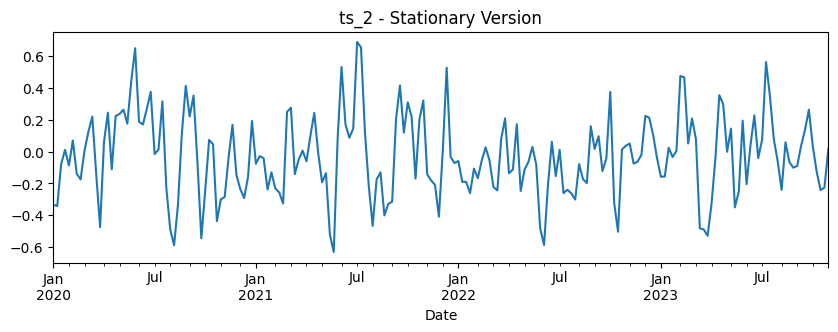

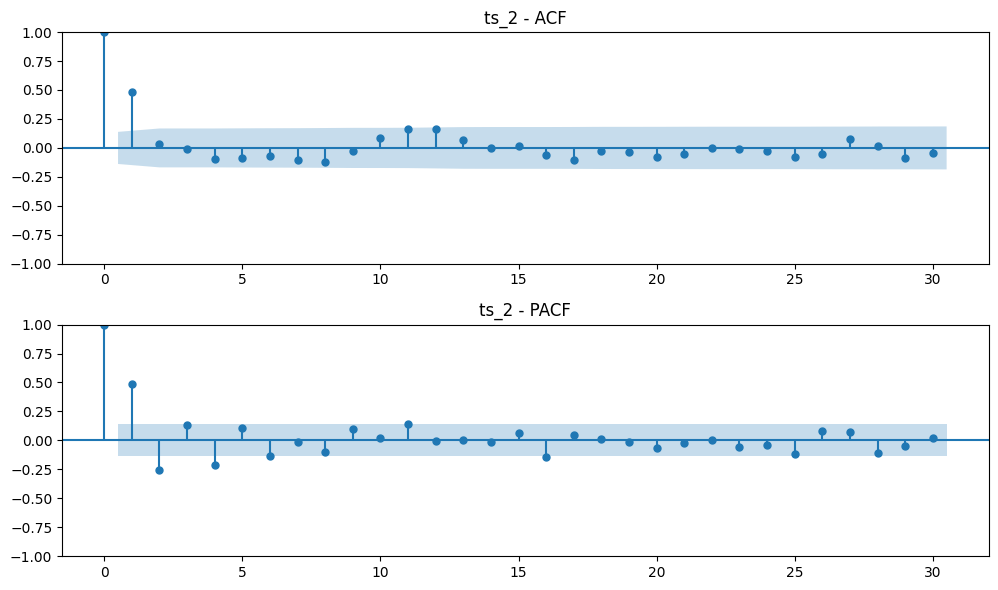

Interpretation guide:
PACF cutoff → choose p
ACF cutoff  → choose q
Final model form: ARIMA(p, 0, q)
Analysis for ts_3


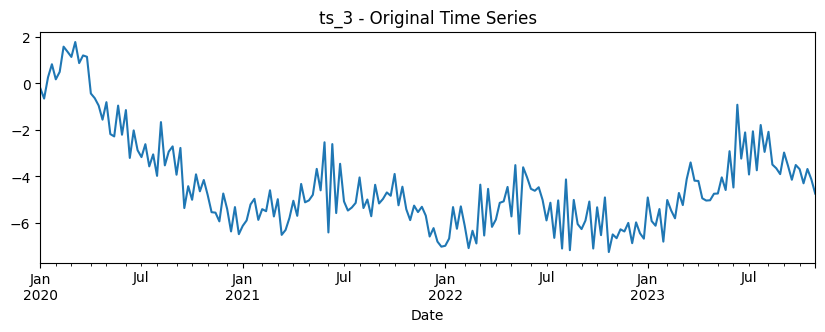

ADF p-value: 0.15152
Stationary: No
Suggested d from ndiffs: 1
Using differenced data with d = 1


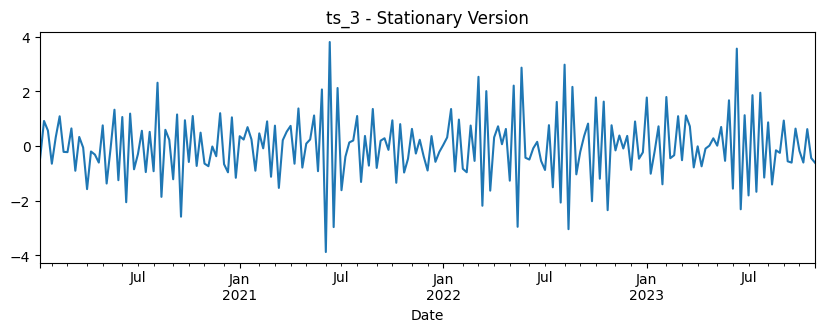

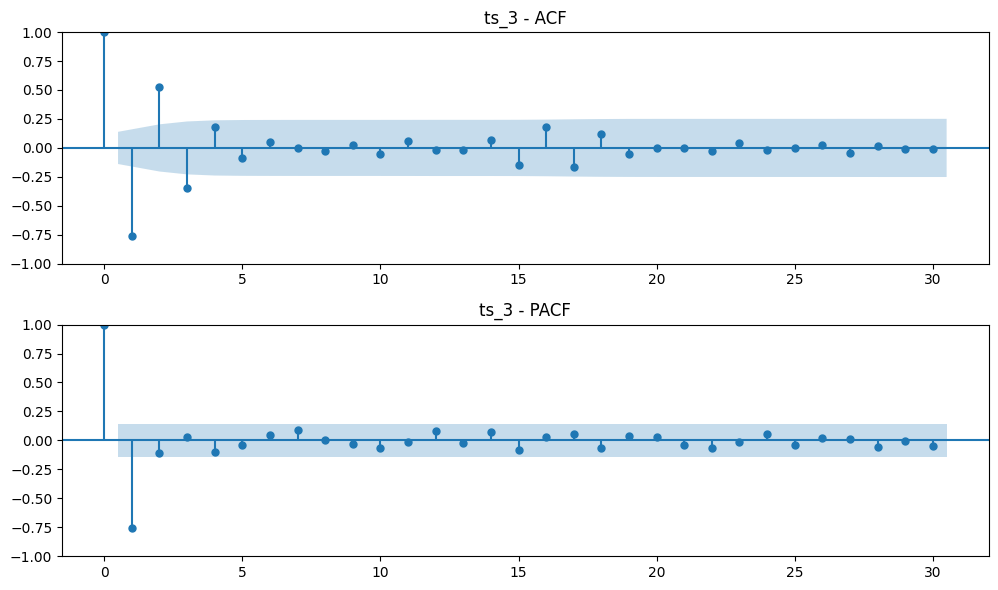

Interpretation guide:
PACF cutoff → choose p
ACF cutoff  → choose q
Final model form: ARIMA(p, 1, q)
Analysis for ts_4


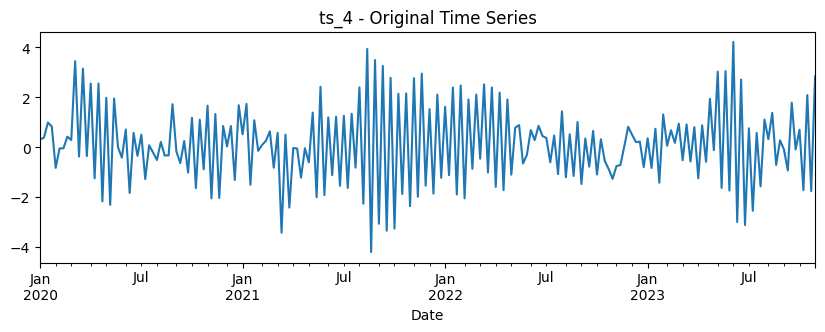

ADF p-value: 0.00000
Stationary: Yes
Suggested d from ndiffs: 0
Using original data because d = 0


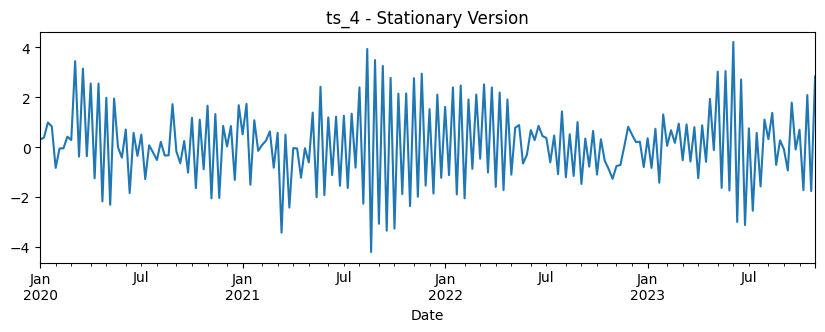

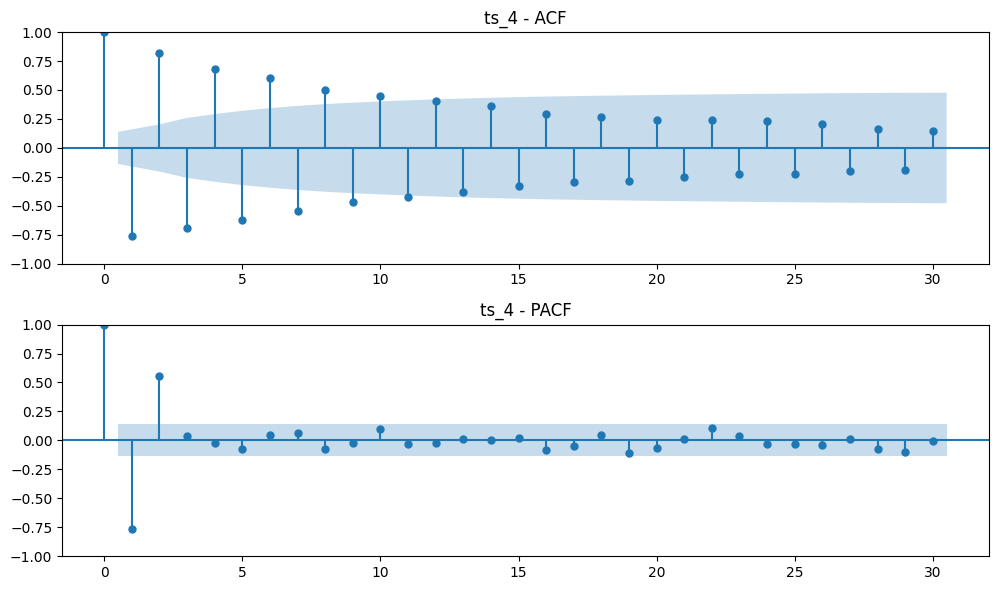

Interpretation guide:
PACF cutoff → choose p
ACF cutoff  → choose q
Final model form: ARIMA(p, 0, q)
Analysis for ts_5


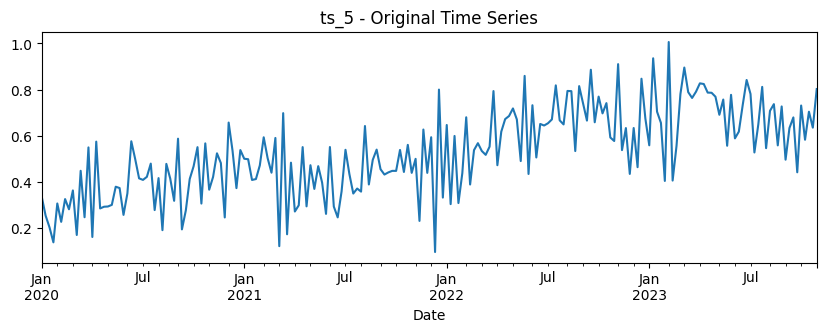

ADF p-value: 0.25022
Stationary: No
Suggested d from ndiffs: 1
Using differenced data with d = 1


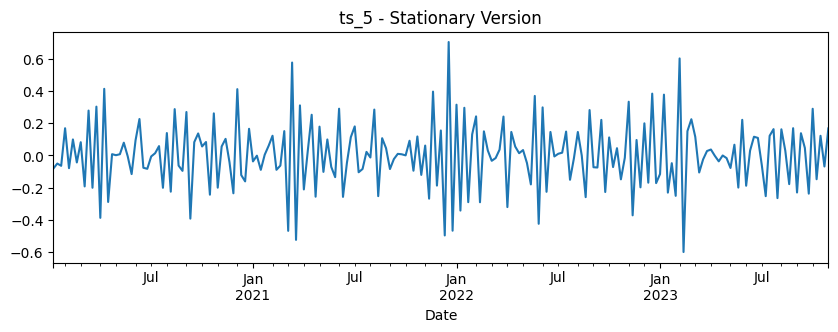

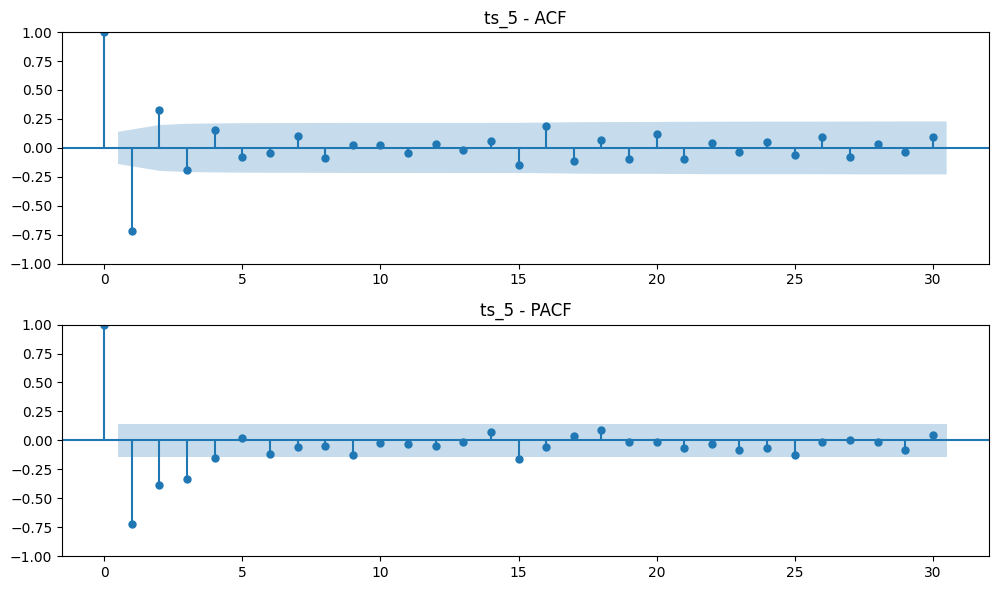

Interpretation guide:
PACF cutoff → choose p
ACF cutoff  → choose q
Final model form: ARIMA(p, 1, q)
Analysis for ts_6


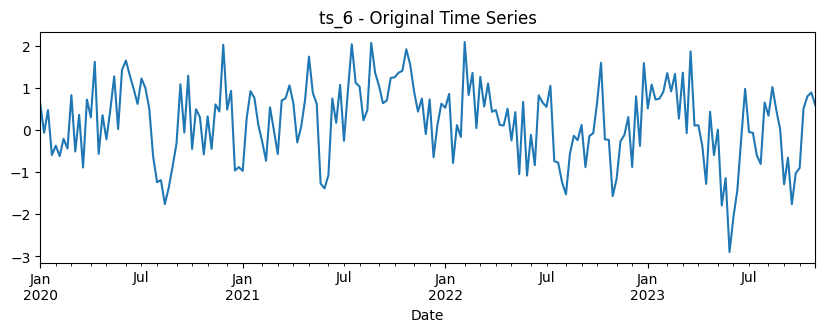

ADF p-value: 0.00157
Stationary: Yes
Suggested d from ndiffs: 0
Using original data because d = 0


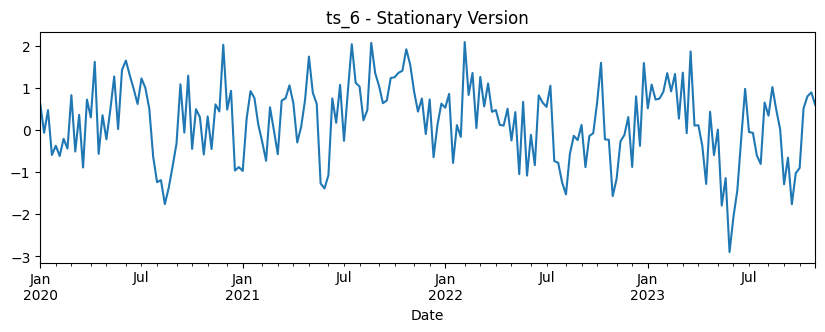

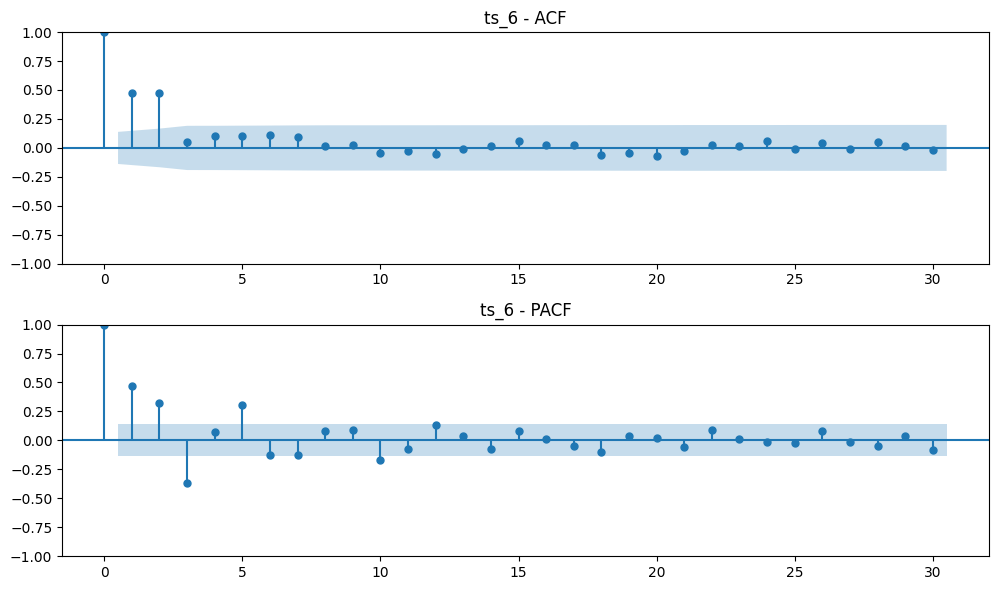

Interpretation guide:
PACF cutoff → choose p
ACF cutoff  → choose q
Final model form: ARIMA(p, 0, q)


In [7]:
for name, ts in series_list.items():
    analyze_time_series(ts, name)

## Model Order Selection Summary

| Time Series | Stationary? | Differencing Order (d) | ACF/PACF Interpretation                                   | Suggested Model |
| ----------- | ----------: | ---------------------: | --------------------------------------------------------- | --------------- |
| `ts_1`      |         Yes |                      0 | PACF cuts off at lag 1                                    | `ARIMA(1,0,0)`  |
| `ts_2`      |         Yes |                      0 | ACF cuts off around lag 1                                 | `ARIMA(0,0,1)`  |
| `ts_3`      |          No |                      1 | Both ACF and PACF show important lag 1 after differencing | `ARIMA(1,1,1)`  |
| `ts_4`      |         Yes |                      0 | PACF cuts off around lag 2                                | `ARIMA(2,0,0)`  |
| `ts_5`      |          No |                      1 | ACF cuts off around lag 2 after differencing              | `ARIMA(0,1,2)`  |
| `ts_6`      |         Yes |                      0 | ACF cuts off around lag 2                                 | `ARIMA(0,0,2)`  |

### Final Model Interpretation

* `ts_1` → AR(1)
* `ts_2` → MA(1)
* `ts_3` → ARMA with differencing → ARIMA(1,1,1)
* `ts_4` → AR(2)
* `ts_5` → MA(2) with differencing → ARIMA(0,1,2)
* `ts_6` → MA(2)
